In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pickle
from stepmix.stepmix import StepMix
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [ ]:
# Loading cNMF usage results (K=200 programs)
pkl_path = 'Prod1_neuron_usage_per_perturbation.pkl'
with open(pkl_path, 'rb') as f:
    usage_data = pickle.load(f)
df_raw = usage_data['result_k_200'].copy()
df_raw

,Usage_1,Usage_2,Usage_3,Usage_4,Usage_5,Usage_6,Usage_7,Usage_8,Usage_9,Usage_10,...,Usage_191,Usage_192,Usage_193,Usage_194,Usage_195,Usage_196,Usage_197,Usage_198,Usage_199,Usage_200
ABAT_P1,0.096213,0.091626,0.081691,0.088342,0.062515,0.080773,0.068013,0.052156,0.044186,0.035296,...,0.000239,0.000054,0.000050,0.000032,0.000137,0.000031,0.000034,0.000034,0.000009,0.000051
ABAT_P2,0.100672,0.089661,0.084540,0.081183,0.072315,0.081806,0.061769,0.056764,0.044251,0.036899,...,0.000062,0.000041,0.000027,0.000023,0.000116,0.000026,0.000032,0.000030,0.000007,0.000048
ABCA10_P1P2,0.102709,0.094179,0.085541,0.085112,0.065326,0.083004,0.066094,0.050462,0.050402,0.036206,...,0.000064,0.000042,0.000021,0.000041,0.000109,0.000024,0.000036,0.000022,0.000009,0.000050
ABCA13_P1P2,0.106025,0.092822,0.083546,0.084167,0.063635,0.079383,0.064089,0.057344,0.045757,0.036287,...,0.000058,0.000046,0.000044,0.000029,0.000154,0.000022,0.000043,0.000063,0.000006,0.000042
ABCA7_P1,0.099280,0.088582,0.075441,0.084419,0.074088,0.067439,0.073198,0.043817,0.056450,0.038112,...,0.000052,0.000034,0.000062,0.000043,0.000531,0.000096,0.000012,0.000051,0.000014,0.000060
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
POLR1D,0.083394,0.083430,0.089456,0.091698,0.051017,0.061371,0.093739,0.044318,0.044135,0.039369,...,0.000170,0.000076,0.000019,0.000018,0.000010,0.000040,0.000033,0.000029,0.000004,0.000086
PPP1R14B,0.106389,0.093597,0.084808,0.087692,0.069137,0.075693,0.064787,0.049956,0.050581,0.035693,...,0.000056,0.000056,0.000035,0.000058,0.000143,0.000022,0.000039,0.000051,0.000016,0.000054
PRDX6,0.101194,0.094283,0.082735,0.089252,0.069899,0.076708,0.069830,0.051308,0.047374,0.035287,...,0.000076,0.000065,0.000035,0.000109,0.000124,0.000020,0.000031,0.000033,0.000010,0.000054
PTMA,0.092947,0.090941,0.082076,0.093486,0.060979,0.086068,0.073753,0.052375,0.040750,0.032552,...,0.000080,0.000043,0.000027,0.000061,0.000136,0.000018,0.000112,0.000041,0.000007,0.000056


In [ ]:
#Loading cell counts to filter and use as a covariate
region_pkl = 'Prod1_neuronal_cell_region_df.pkl'
with open(region_pkl, 'rb') as f:
    region_df = pickle.load(f)
region_df
cell_counts = region_df.sum(axis=0)
valid_genes = cell_counts[cell_counts >= 100].index.tolist()

,ABAT_P1,ABAT_P2,ABCA10_P1P2,ABCA13_P1P2,ABCA7_P1,ABCA7_P2,ABCE1_P1P2,ABHD11_P1P2,ABL2_P1,ABL2_P2,...,OR9I1,OR9K2,OR9Q1,ORAI1,OST4,POLR1D,PPP1R14B,PRDX6,PTMA,ZFAND6
AAACCTGAGAAACGCC-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAACCTGAGAACTGTA-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAACCTGAGAATGTTG-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAACCTGAGACTAAGT-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAACCTGAGAGTGAGA-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCATCTCGATGA-24,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TTTGTCATCTGTCAAG-24,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TTTGTCATCTGTGCAA-24,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
TTTGTCATCTTCTGGC-24,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
#Read in file which lists the target pertubations and get their usage data
sig_df = pd.read_csv('perturbation_filtering.csv')
list_sig_prog = sig_df['non_controls'].dropna().tolist()
df_filtered = df_raw.loc[df_raw.index.intersection(list_sig_prog)]
df_filtered = df_filtered.loc[df_filtered.index.intersection(valid_genes)]
df_filtered

,non_controls,GP_hits,edist_hits
0,AARS_P1P2,CSDE1_P1P2,ACVR2A_P1P2
1,ABAT_P1,CSNK2B_P1P2,AGO2_P1P2
2,ABAT_P2,CHAMP1_P1P2,AP2M1_P1
3,ABCA10_P1P2,AP2S1_P1P2,BCL7B_P1P2
4,ABCA13_P1P2,JARID2_P1P2,CASKIN1_P1P2
...,...,...,...
1549,LOC101926943,NaN,NaN
1550,LINC01003,NaN,NaN
1551,CNTNAP3,NaN,NaN
1552,PTCHD1-AS,NaN,NaN


In [ ]:
#Baseline Subtraction
ntc_profile = df_filtered.loc['non']
df_transformed = df_filtered.sub(ntc_profile, axis=1).drop('non', axis=0)
df_transformed

,Usage_1,Usage_2,Usage_3,Usage_4,Usage_5,Usage_6,Usage_7,Usage_8,Usage_9,Usage_10,...,Usage_191,Usage_192,Usage_193,Usage_194,Usage_195,Usage_196,Usage_197,Usage_198,Usage_199,Usage_200
ABAT_P1,-0.006879,-0.002352,-0.001419,-0.000974,-0.004919,0.001518,-0.001289,0.000108,-0.003652,0.000498,...,0.000162,-0.000013,1.204900e-05,-6.564678e-06,-6.790701e-06,3.258406e-06,-0.000005,-0.000021,-0.000009,-0.000014
ABAT_P2,-0.002420,-0.004317,0.001430,-0.008134,0.004881,0.002551,-0.007533,0.004715,-0.003587,0.002101,...,-0.000015,-0.000026,-1.080847e-05,-1.573551e-05,-2.725080e-05,-2.077427e-06,-0.000008,-0.000025,-0.000012,-0.000016
ABCA10_P1P2,-0.000383,0.000201,0.002431,-0.004204,-0.002109,0.003749,-0.003208,-0.001586,0.002564,0.001408,...,-0.000012,-0.000026,-1.718677e-05,2.359137e-06,-3.428514e-05,-4.154048e-06,-0.000004,-0.000033,-0.000010,-0.000014
ABCA13_P1P2,0.002933,-0.001156,0.000436,-0.005150,-0.003800,0.000128,-0.005213,0.005296,-0.002080,0.001489,...,-0.000019,-0.000021,6.556458e-06,-9.088504e-06,1.036707e-05,-6.368044e-06,0.000003,0.000007,-0.000013,-0.000022
ABCA7_P1,-0.003812,-0.005396,-0.007669,-0.004897,0.006654,-0.011816,0.003896,-0.008231,0.008613,0.003314,...,-0.000025,-0.000034,2.435342e-05,4.803802e-06,3.877925e-04,6.776055e-05,-0.000028,-0.000005,-0.000004,-0.000004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MIR590,-0.011729,-0.011795,-0.006508,0.006232,-0.007203,0.008777,-0.003534,-0.008732,0.001658,-0.004245,...,0.000032,-0.000018,-2.773304e-05,1.468031e-05,-1.287413e-05,-3.625506e-07,-0.000014,-0.000004,-0.000014,-0.000016
LOC101926943,-0.002700,0.003289,0.002273,0.000761,-0.003639,-0.000074,0.003057,-0.001132,-0.001853,-0.002990,...,-0.000022,0.000007,1.858345e-06,-1.066542e-05,3.093813e-05,-3.883397e-06,-0.000007,0.000006,-0.000008,0.000160
LINC01003,-0.003867,-0.002140,0.000916,0.000806,-0.002372,0.001190,-0.000459,-0.001486,-0.000981,0.000573,...,-0.000004,0.000100,1.343274e-06,-3.830389e-06,1.533209e-04,-4.083993e-06,-0.000011,-0.000025,-0.000008,-0.000011
CNTNAP3,-0.005699,-0.000228,-0.002551,0.003462,-0.004020,0.001091,0.003497,-0.001259,-0.002793,-0.000710,...,0.000062,-0.000006,4.131837e-06,-9.778370e-08,-8.157007e-06,1.100119e-05,-0.000006,-0.000018,-0.000010,-0.000011


In [ ]:
#Feature Scaling (Z-score)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(df_transformed), 
                         index=df_transformed.index, columns=df_transformed.columns)


In [ ]:
# Define Covariate Z
Z_raw = cell_counts.loc[X_scaled.index]
Z = np.log1p(Z_raw).values.reshape(-1, 1)

array([[7.68432407],
       [6.23244802],
       [6.19847872],
       ...,
       [8.41891862],
       [8.40402449],
       [6.81673588]], shape=(1499, 1))

In [ ]:
#EXPLORATORY CLASS ENUMERATION (200 RUNS)
n_components_range = range(2, 16)
n_runs = 200 
metrics_list = []

In [17]:
print(f"Starting Exploratory Class Enumeration: K=2-15, {n_runs} runs per K...")

for n in n_components_range:
    print(n)
    run_stats = []
    for i in range(n_runs):
        # We use random_state=i to ensure each of the 200 runs is independent
        # n_init=1 is used because the 200 outer loops handle the initialization variety
        model = StepMix(n_components=n, measurement='gaussian', structural='covariate', 
                        n_init=1, random_state=i)
        model.fit(X_scaled, Z)
        
        # Collect built-in Litman metrics
        run_stats.append([
            model.score(X_scaled, Z) * len(X_scaled), # LL
            model.aic(X_scaled, Z),                  # AIC
            model.bic(X_scaled, Z),                  # BIC
            model.sabic(X_scaled, Z),                # SABIC/CABIC
            model.caic(X_scaled, Z),                 # CAIC
            model.relative_entropy(X_scaled, Z)      # Entropy
        ])
    
    # Aggregate Mean and Std Dev for stability visualization (error bars)
    means = np.mean(run_stats, axis=0)
    stds = np.std(run_stats, axis=0)
    
    metrics_list.append({
        'n': n,
        'LL_m': means[0], 'LL_s': stds[0],
        'AIC_m': means[1], 'AIC_s': stds[1],
        'BIC_m': means[2], 'BIC_s': stds[2],
        'SABIC_m': means[3], 'SABIC_s': stds[3],
        'CAIC_m': means[4], 'CAIC_s': stds[4],
        'Ent_m': means[5], 'Ent_s': stds[5]
    })
    print(f"Finished K={n}")

m_df = pd.DataFrame(metrics_list)

Starting Exploratory Class Enumeration: K=2-15, 200 runs per K...
2
Fitting StepMix...


Initializations (n_init) : 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.30it/s, max_LL=-4.18e+5, max_avg_LL=-279]


Fitting StepMix...


Initializations (n_init) : 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.57it/s, max_LL=-4.18e+5, max_avg_LL=-279]


Fitting StepMix...


...

Fitting StepMix...


Initializations (n_init) : 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:08<00:00,  8.64s/it, max_LL=-4.09e+5, max_avg_LL=-273]


Fitting StepMix...


Initializations (n_init) : 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:23<00:00, 23.29s/it, max_LL=-4.09e+5, max_avg_LL=-273]


Finished K=15


In [18]:
X_scaled.to_csv('processed_molecular_signatures_woControl.csv')
m_df.to_csv("metrics_woControl.csv")

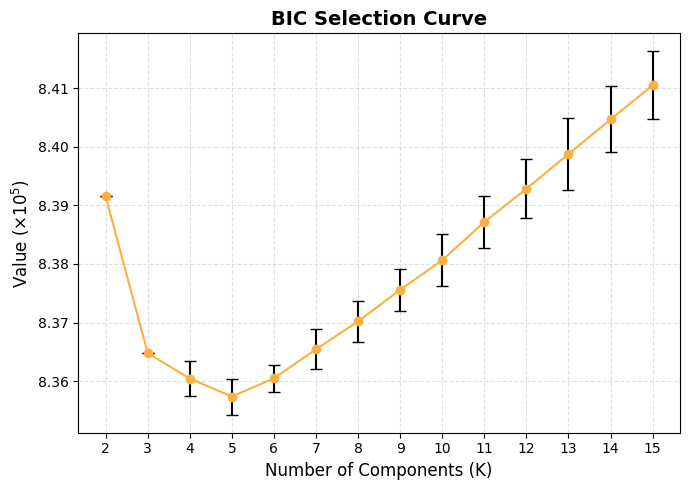

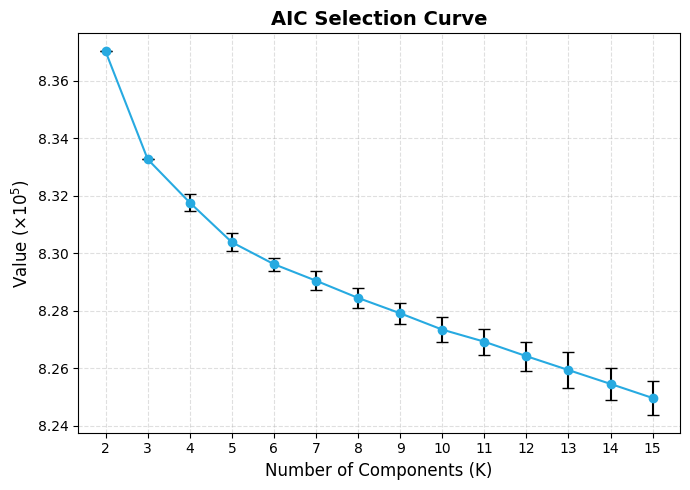

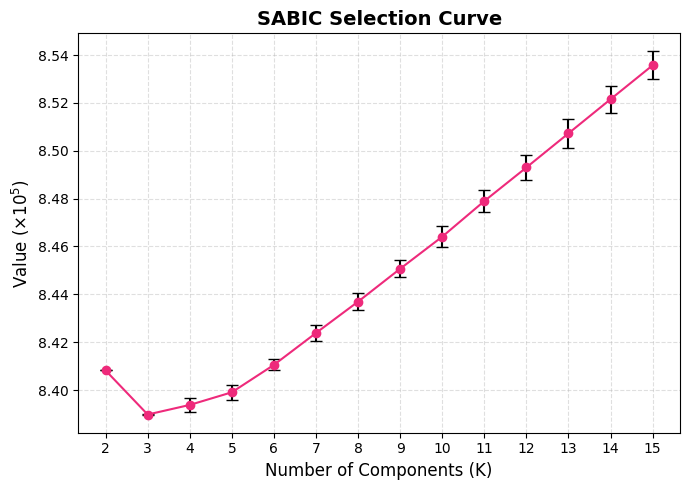

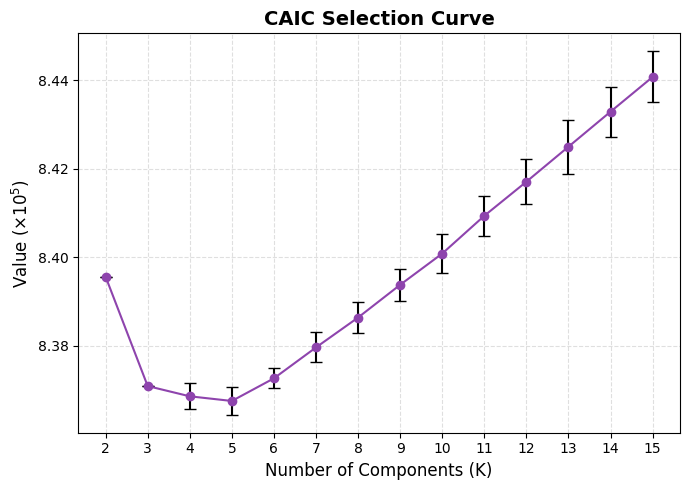

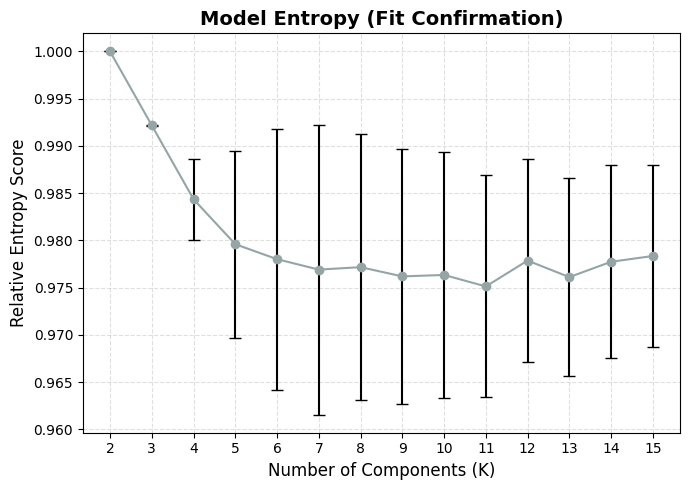

In [ ]:
#Plotting
def plot_final(df, mean_col, std_col, title, filename, color):
    plt.figure(figsize=(7, 5))
    
    # Scale huge values for readability, except for Entropy
    is_ent = 'Ent' in mean_col
    denom = 1e5 if not is_ent else 1.0
    
    plt.errorbar(df['n'], df[mean_col]/denom, yerr=df[std_col]/denom, 
                 fmt='-o', color=color, ecolor='black', capsize=4, markersize=6)
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Number of Components (K)', fontsize=12)
    plt.ylabel(r'Value ($\times 10^5$)' if not is_ent else 'Relative Entropy Score', fontsize=12)
    
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.xticks(df['n']) # Ensure every K is labeled on x-axis
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

# Generate the 5 distinct plots used by Litman for selection
plot_final(m_df, 'BIC_m', 'BIC_s', 'BIC Selection Curve', 'Litman_BIC_woControl.png', '#FBB040')
plot_final(m_df, 'AIC_m', 'AIC_s', 'AIC Selection Curve', 'Litman_AIC_woControl.png', '#27AAE1')
plot_final(m_df, 'SABIC_m', 'SABIC_s', 'SABIC Selection Curve', 'Litman_SABIC_woCOntrol.png', '#EE2A7B')
plot_final(m_df, 'CAIC_m', 'CAIC_s', 'CAIC Selection Curve', 'Litman_CAIC_woControl.png', '#8E44AD')
plot_final(m_df, 'Ent_m', 'Ent_s', 'Model Entropy (Fit Confirmation)', 'Litman_Entropy_woControl.png', '#95A5A6')

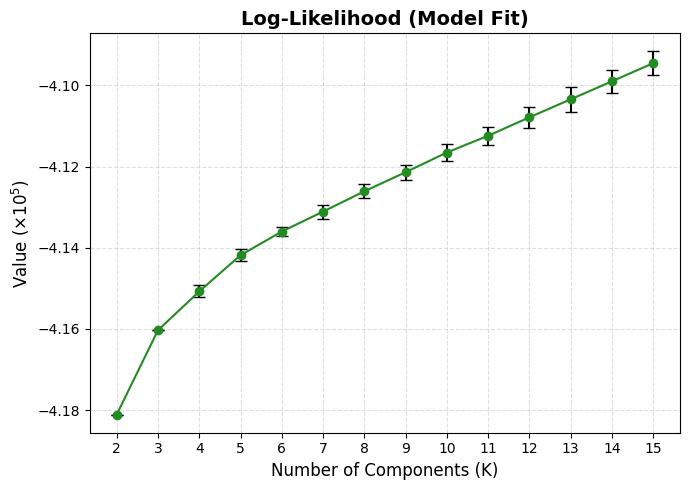

In [ ]:
plot_final(m_df, 'LL_m', 'LL_s', 'Log-Likelihood (Model Fit)', 'Litman_LL_woControl.png', '#228B22')

In [ ]:
#Production Model Fitting (K=5)
print("Running final production model (K=5, n_init=200)...")

# We use n_init=200 here to find the global maximum for the chosen K
final_model = StepMix(
    n_components=5, 
    measurement='gaussian', 
    structural='covariate', 
    n_init=200, 
    random_state=42
)

final_model.fit(X_scaled, Z)

Running final production model (K=5, n_init=200)...
Fitting StepMix...


Initializations (n_init) :   3%|███                                                                                                 | 6/200 [00:34<17:04,  5.28s/it, max_LL=-4.14e+5, max_avg_LL=-276]

In [ ]:
model_filename = 'Model_K5.pkl'
with open(model_filename, 'wb') as f:
    pickle.dump(final_model, f)

In [ ]:
#Hard Assignments
assignments = final_model.predict(X_scaled, Z)
#Soft Assignments 
probs = final_model.predict_proba(X_scaled, Z)

In [ ]:
# Create a final clean DataFrame
class_cols = [f'Class_{i}' for i in range(5)]
results_df = pd.DataFrame(probs, index=X_scaled.index, columns=class_cols)
results_df['Assignment'] = assignments

# Save the final results
results_df.to_csv('Final_Gene_Class_Assignments_K5.csv')

In [ ]:
#Calculate Class Profiles (Mean Program Usage per Class)
X_with_assignments = X_scaled.copy()
X_with_assignments['Class'] = assignments
class_profiles = X_with_assignments.groupby('Class').mean()
class_profiles.to_csv('Class_Profiles_K5_Means.csv')

In [ ]:
for i in range(5):
    top_progs = class_profiles.loc[i].sort_values(ascending=False).head(3)
    print(f"\nClass {i}:")
    for prog, val in top_progs.items():
        print(f"  - {prog}: {val:.2f}")

In [ ]:
#Create the Histogram of Perturbations per Class
plt.figure(figsize=(8, 6))
# Count how many perturbations are in each class
class_counts = pd.Series(assignments).value_counts().sort_index()
bars = plt.bar(class_counts.index, class_counts.values, color='#34495E', alpha=0.8)

# Add labels and styling
plt.title('Distribution of Perturbations per Class (K=5)', fontsize=14, fontweight='bold')
plt.xlabel('Class Assignment', fontsize=12)
plt.ylabel('Number of Perturbations', fontsize=12)
plt.xticks(range(5))

# Add the count labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('Perturbation_Histogram_K5.png', dpi=300)
plt.show()

In [ ]:
class_profiles = pd.read_csv('Class_Profiles_K5_Means.csv', index_col=0)

<Figure size 2000x800 with 0 Axes>

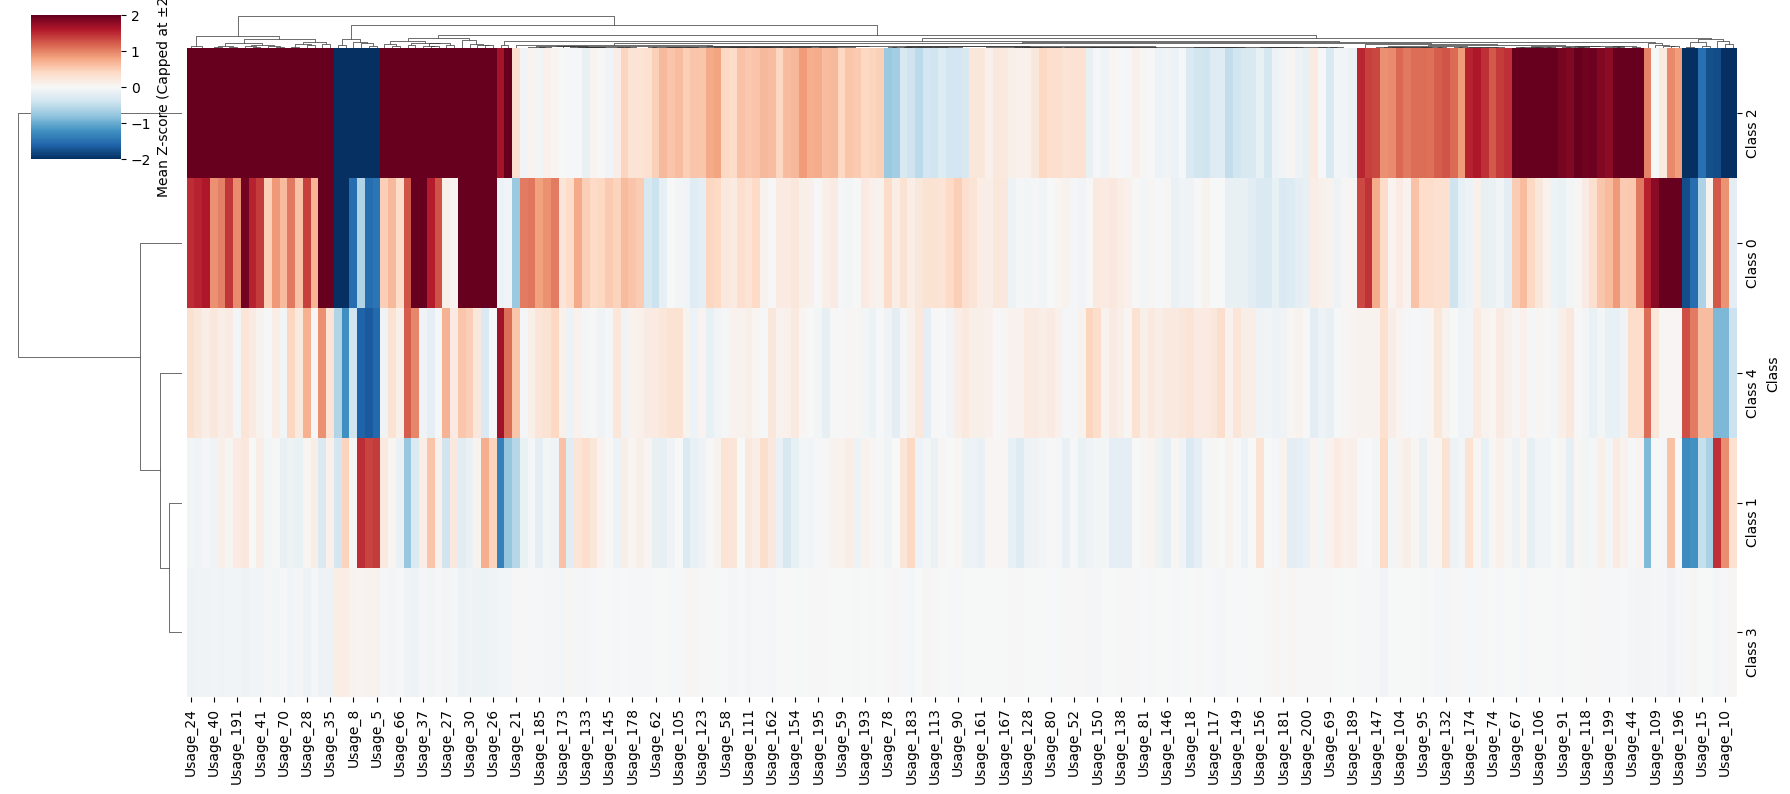

In [ ]:
# Define the 'Clip' value. 
v_limit = 2.0 

plt.figure(figsize=(20, 8))

g = sns.clustermap(
    class_profiles, 
    cmap='RdBu_r', 
    center=0,
    vmin=-v_limit, 
    vmax=v_limit, 
    figsize=(18, 8),
    cbar_kws={'label': f'Mean Z-score (Capped at ±{v_limit})'},
    yticklabels=[f'Class {i}' for i in class_profiles.index],
    dendrogram_ratio=(.1, .05)
)